## Full dataset inter-annotator agreement

This notebook includes inter-annotator agreement (Krippendorff's &alpha;) and accuracy (percentage of agreed-upon annotations) evaluations for the entire dataset. Additionally, we analyse the label distribution for the dataset for both the 6-class and 3-class schema.

The visualisations in the notebook are also available in [Figures folder](../Figures/).

In [22]:
import pandas as pd
import csv
import krippendorff
import numpy as np

In [23]:
df = pd.read_csv('../Annotations/annotations.csv', delimiter=",", encoding='utf-8')
df = df.drop(columns=['id'])
df

,text,timestamp_tamara,flagged_tamara,comment_tamara,tag_tamara,timestamp_anze,flagged_anze,comment_anze,tag_anze,timestamp_katja,flagged_katja,comment_katja,tag_katja,rev_tamara,rev_anze,rev_katja,final_tag,notes,disagreement
0,"Tako kot sem uvodoma povedal, še vedno mislim,...",2023-02-23 10:08:33,NaN,NaN,P_Neutral,2023-02-23 10:05:56,NaN,It is posible to see documents,P_Neutral,1677143150,NaN,"Statement, but expresses positive hope",P_Neutral,NaN,NaN,NaN,P_Neutral,NaN,NaN
1,"Manj ko je beguncev, večji je odpor pred temi ...",2023-02-23 10:09:11,NaN,No direct opinion by the speaker.,N_Neutral,2023-02-23 10:06:26,NaN,NaN,Negative,1677143163,NaN,NaN,Negative,No direct opinion by the speaker.,"Opinion not expressed directly, but implied","Opinion not expressed directly, but implied",Negative,NaN,NaN
2,"Drugo vprašanje, ki ste ga izpostavili, je vpr...",2023-02-23 10:09:34,NaN,NaN,P_Neutral,2023-02-23 10:07:22,NaN,NaN,Positive,1677143249,NaN,"Neutral, factual statement",NaN,No direct opinion by the speaker.,Positive topic (socialni dialog),"Neutral, factual statement, not direct opinion",P_Neutral,NaN,NaN
3,Če se lahko tako izrazim; »pravica« biti deleg...,2023-02-23 10:10:37,NaN,Sarcasm.,N_Neutral,2023-02-23 10:09:08,NaN,Positive thinking,P_Neutral,1677143451,NaN,Slight sarcasm,N_Neutral,Sarcasm,Because position will be formed,"Sarcasm, otherwise neutral",N_Neutral(S),NaN,NaN
4,"Seveda, kjerkoli zavrtajo v Prekmurju, tam pri...",2023-02-23 10:10:57,NaN,Sarcasm.,N_Neutral,2023-02-23 10:10:21,NaN,S,P_Neutral,1677143466,NaN,Sarcasm,NaN,Sarcasm,Sarcasm,Degrading connotation,N_Neutral(S),NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2595,Ustavno sodišče je zavrglo pobudo državnega zb...,2023-06-15 23:58:35,NaN,statement,N_Neutral,NaN,NaN,NaN,NaN,2023-06-19 18:21:47,NaN,NaN,N_Neutral,NaN,NaN,NaN,N_Neutral,NaN,0.0
2596,"Sama, kot predstavnica mlajše generacije, želi...",2023-06-15 23:59:02,NaN,"positive sentiment, but not string enough to b...",P_Neutral,NaN,NaN,NaN,NaN,2023-06-19 18:22:32,1.0,NaN,N_Neutral,NaN,NaN,I have no idea what I was thinking here.,P_Neutral,NaN,1.0
2597,Kakor hitro gre za vprašanje izplačila odškodn...,2023-06-15 23:59:09,NaN,NaN,Negative,NaN,NaN,NaN,NaN,2023-06-19 18:22:38,NaN,NaN,Negative,NaN,NaN,NaN,Negative,NaN,0.0
2598,"Če gledamo te velike nakupovalne centre, saj v...",2023-06-15 23:59:22,NaN,statement,P_Neutral,NaN,NaN,NaN,NaN,2023-06-19 18:22:53,NaN,NaN,P_Neutral,NaN,NaN,NaN,P_Neutral,NaN,0.0


In [24]:
tag_cols = ['tag_tamara', 'tag_katja']
tags = df[tag_cols]
tags = df[tag_cols].dropna()

tags

,tag_tamara,tag_katja
0,P_Neutral,P_Neutral
1,N_Neutral,Negative
3,N_Neutral,N_Neutral
5,N_Neutral,Negative
6,N_Neutral,N_Neutral
...,...,...
2595,N_Neutral,N_Neutral
2596,P_Neutral,N_Neutral
2597,Negative,Negative
2598,P_Neutral,P_Neutral


-----------

In [26]:
tag_cols = ['tag_tamara', 'tag_katja']

# Keep only items annotated by both annotators
tags = df[tag_cols].copy()

unique_tags = pd.unique(tags.values.ravel())
unique_tags = [x for x in unique_tags if pd.notna(x)]

tag_to_code = {label: idx for idx, label in enumerate(unique_tags)}

for col in tag_cols:
    tags[col + '_6class'] = tags[col].map(tag_to_code)

data_6class = tags[[col + '_6class' for col in tag_cols]].to_numpy(dtype=float).T

alpha_6class = krippendorff.alpha(
    reliability_data=data_6class,
    level_of_measurement='nominal'
)

print("KA 6-class:", alpha_6class)

KA 6-class: 0.5099808584431593


In [27]:
print(tag_to_code)

{'P_Neutral': 0, 'N_Neutral': 1, 'Negative': 2, 'Positive': 3, 'M_Negative': 4, 'M_Positive': 5}


In [6]:
mapping_3class = {
    'Positive': 'Positive',
    'M_Positive': 'Positive',    
    'Negative': 'Negative',
    'M_Negative': 'Negative',
    'P_Neutral': 'Neutral',
    'N_Neutral': 'Neutral',
    }

for col in tag_cols:
    df[col + '_3class'] = df[col].map(mapping_3class)

unique_tag3 = pd.unique(df[[col + "_3class" for col in tag_cols]].values.ravel())
unique_tag3 = [x for x in unique_tag3 if pd.notna(x)]

tag_to_code3 = {label: idx for idx, label in enumerate(unique_tag3)}

for col in tag_cols:
    df[col + '_3code'] = df[col + '_3class'].map(tag_to_code3)

data_3class = df[[col + '_3code' for col in tag_cols]].to_numpy().T

alpha_3class = krippendorff.alpha(
    reliability_data=data_3class, 
    level_of_measurement="nominal")

In [7]:
print("KA 3-class score: ", alpha_3class)

KA 3-class score:  0.5382469074474283


## Agreement calculation

Due to missing annotations in the pilot data, percentage agreement was calculated using a complete-case approach. Only items for which all annotators provided a label were included in the calculation. An item was counted as an agreement if all annotators assigned the same category; items with missing annotations were excluded from the agreement calculation.

For pilot 1, which involved three annotators, agreement was counted only when all three annotators assigned the same label. For the main annotations, which involved two annotators, agreement was counted when both annotators assigned the same label.

In [8]:
def percent_agreement_complete(rows):
    if rows.isna().any():
        return np.nan
    return int(len(set(rows)) == 1)

agreement_6 = (
    df[tag_cols]
    .apply(percent_agreement_complete, axis=1)
    .mean()
)

agreement_3 = (
    df[[col + '_3class' for col in tag_cols]]
    .apply(percent_agreement_complete, axis=1)
    .mean()
)

print("Agreement for a 6-class schema: ", (agreement_6 * 100))
print("Agreement for a 3-class schema: ", (agreement_3 * 100))

Agreement for a 6-class schema:  64.69642139123441
Agreement for a 3-class schema:  74.26618415761962


# Final tag distribution

In [9]:
df['final_tag'] = df['final_tag'].astype("str").str.strip().str.replace(r"\(S\)", "", regex=True)
mapping_mistakes = {
'Negative.' : 'Negative',
'Postive':'Positive',
'Negatvie': 'Negative',
'N_Negative':'M_Negative',
'Negative ': 'Negative'
}
df['final_tag'] = df['final_tag'].map(mapping_mistakes).fillna(df['final_tag'])
df['final_tag'].unique()


array(['P_Neutral', 'Negative', 'N_Neutral', 'M_Negative', 'Positive',
       'M_Positive'], dtype=object)

In [10]:
label6 = df['final_tag'].value_counts()
label6

final_tag
Negative      966
P_Neutral     750
N_Neutral     659
Positive      138
M_Negative     44
M_Positive     43
Name: count, dtype: int64

In [11]:
label_percentage = (label6 / label6.sum()) * 100
label_percentage 

final_tag
Negative      37.153846
P_Neutral     28.846154
N_Neutral     25.346154
Positive       5.307692
M_Negative     1.692308
M_Positive     1.653846
Name: count, dtype: float64

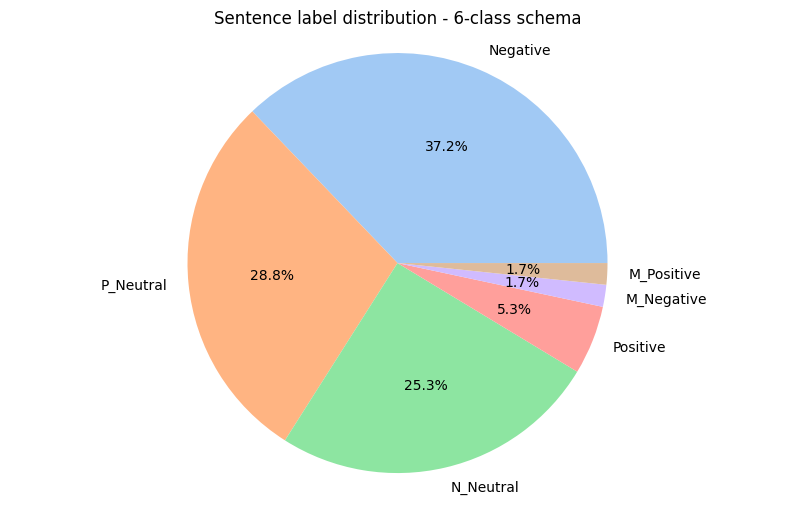

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

palette = sns.color_palette('pastel')

plt.figure(figsize=(10,6))
plt.pie(label_percentage, labels=label_percentage.index, colors=palette, autopct='%1.1f%%')
plt.title('Sentence label distribution - 6-class schema')
plt.axis('equal')
plt.savefig('../Figures/Labels_6class.png', dpi=300)
plt.show()

In [13]:
df['final_tag3'] = df['final_tag'].map(mapping_3class)
df['final_tag3'].unique()

array(['Neutral', 'Negative', 'Positive'], dtype=object)

In [14]:
label3 = df['final_tag3'].value_counts()
label3

final_tag3
Neutral     1409
Negative    1010
Positive     181
Name: count, dtype: int64

In [15]:
sent_percentage = (label3 / label3.sum()) *100
sent_percentage

final_tag3
Neutral     54.192308
Negative    38.846154
Positive     6.961538
Name: count, dtype: float64

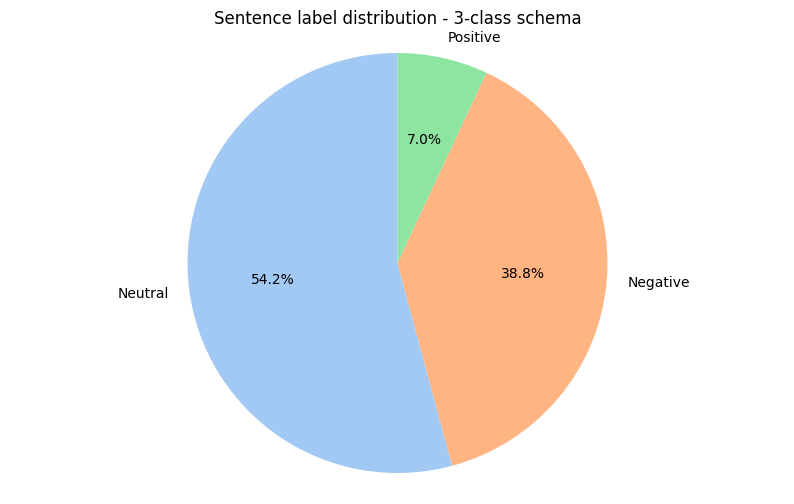

In [16]:
plt.figure(figsize=(10, 6))
plt.pie(sent_percentage, labels=sent_percentage.index, colors=palette, startangle=90, autopct='%1.1f%%')
plt.title('Sentence label distribution - 3-class schema')
plt.axis('equal')
plt.savefig('../Figures/Labels_3class.png', dpi=300)
plt.show()

## KA and ACC scores across the annotation process

In [17]:
scores = pd.read_csv("../Tables/Pilot+Main_agreement.csv", encoding='utf-8')
scores = scores.rename(columns={"phase":'Phase', 'KA_6class':'6-class', 'KA_3class':'3-class'})
scores = scores.drop(columns=['ACC_6class', 'ACC_3class'])
scores

,Phase,6-class,3-class
0,main1,0.4814,0.5082
1,main2,0.5430,0.5735
2,pilot1,0.2566,0.2573
3,pilot2,0.3316,0.3899
4,pilot3,0.3715,0.3870
5,pilot4,0.4754,0.5012
6,pilot5,0.3060,0.3377
7,pilot6,0.4363,0.3749


In [18]:
scores = pd.melt(scores,
                 id_vars=['Phase'], 
                 value_vars=['6-class', '3-class'],
                 var_name='Scale', 
                 value_name='Alpha Score'
)

scores

,Phase,Scale,Alpha Score
0,main1,6-class,0.4814
1,main2,6-class,0.5430
2,pilot1,6-class,0.2566
3,pilot2,6-class,0.3316
4,pilot3,6-class,0.3715
5,pilot4,6-class,0.4754
6,pilot5,6-class,0.3060
7,pilot6,6-class,0.4363
8,main1,3-class,0.5082
9,main2,3-class,0.5735


In [19]:
scores['sort_key'] = scores['Phase'].apply(lambda x: 0 if 'pilot' in x else 1)
scores = scores.sort_values(by='sort_key').drop(columns='sort_key').reset_index(drop=True)
scores

,Phase,Scale,Alpha Score
0,pilot1,6-class,0.2566
1,pilot2,6-class,0.3316
2,pilot3,6-class,0.3715
3,pilot4,6-class,0.4754
4,pilot5,6-class,0.3060
5,pilot6,6-class,0.4363
6,pilot1,3-class,0.2573
7,pilot2,3-class,0.3899
8,pilot3,3-class,0.3870
9,pilot4,3-class,0.5012


In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

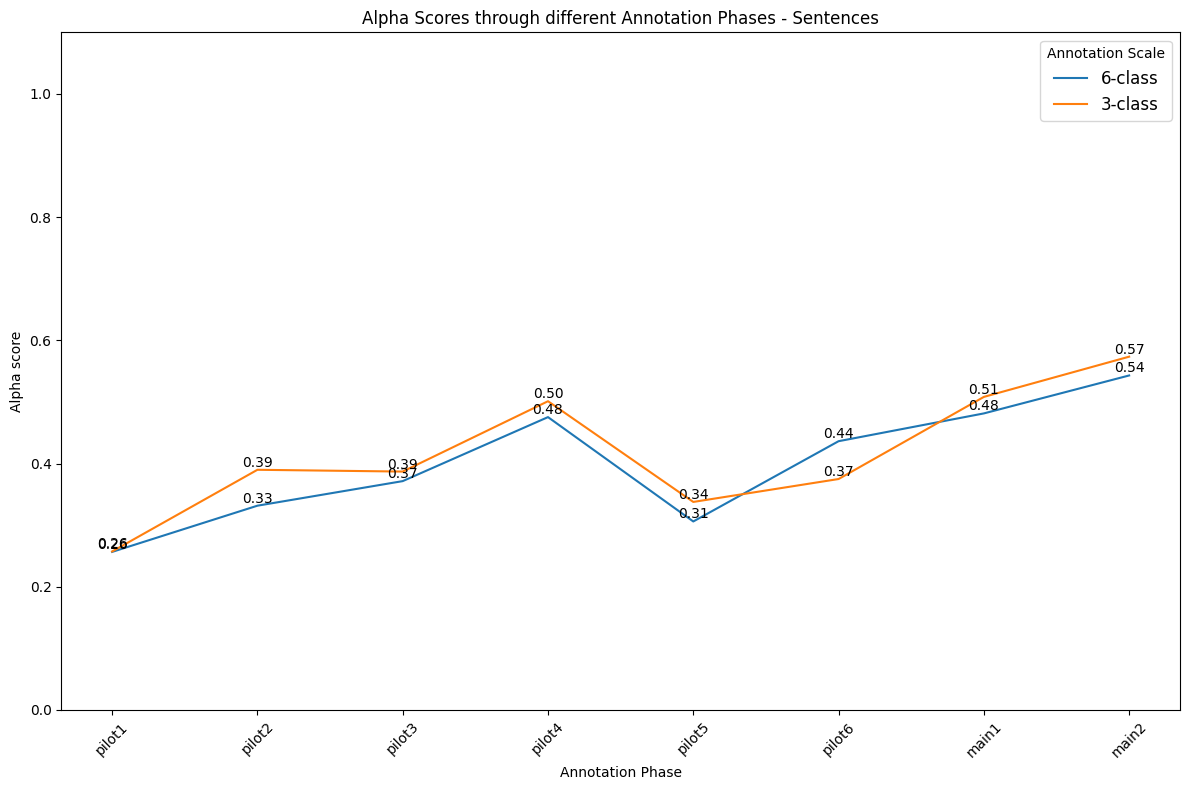

In [21]:
plt.figure(figsize=(12,8))
lineplot = sns.lineplot(data=scores, x="Phase", y="Alpha Score", hue='Scale', markers=True)

plt.title('Alpha Scores through different Annotation Phases - Sentences')
plt.xlabel("Annotation Phase")
plt.ylabel("Alpha score")
plt.legend(title="Annotation Scale", fontsize=12)
plt.xticks(rotation=45)
plt.ylim(0, 1.1)

for line in lineplot.lines:
    for x_data, y_data in zip(line.get_xdata(), line.get_ydata()):
        plt.text(x_data, y_data, f'{y_data:.2f}', fontsize=10, ha='center', va='bottom')

plt.tight_layout()
plt.savefig('../Figures/KA_Tracking.png', dpi=300)
plt.show()